# Basics of geospatial data analysis using Python

Slightly alternative methods to those shown in the demo notebook.

In [1]:
# import modules
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


### Working with vector data

For example, shapefiles

In [2]:
# path to shapefile
rgi_shp_fp = '/Users/albwel/data/rgi70/glaciers/RGI2000-v7.0-G-01_alaska/RGI2000-v7.0-G-01_alaska.shp' # example glacier outlines

# convert shp to dataFrame
rgi_shp_df = gpd.read_file(rgi_shp_fp)
# print(rgi_shp_df, rgi_shp_df.head(), rgi_shp_df.columns) # you can look at the df and see the columns, etc, like some of these

# since this shapefile has many features, let's just select one based on the RGI Id
glacier_df = rgi_shp_df[rgi_shp_df['rgi_id'] == 'RGI2000-v7.0-G-01-05299'].head(1)

# reproject shapefile
glacier_utm_df = glacier_df.to_crs('EPSG:32606')

# check the data coordinate system before and after reprojection -- it worked!
print(glacier_df.crs) 
print(glacier_utm_df.crs)

# we can also calculate the area, for example
print(glacier_utm_df.geometry.area) # sq. meters


EPSG:4326
EPSG:32606
5298    1.755533e+07
dtype: float64


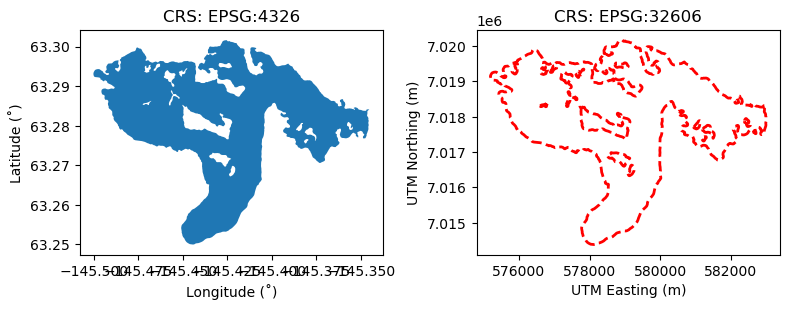

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8,5))
ax1, ax2 = axs

glacier_df.plot(ax=ax1)
ax1.set_xlabel('Longitude (˚)')
ax1.set_ylabel('Latitude (˚)')
ax1.set_title(f'CRS: {glacier_df.crs}')

# also, you can play around with visualization settings
glacier_utm_df.plot(ax=ax2, color='none', edgecolor='r', linewidth=2, linestyle='--')
ax2.set_xlabel('UTM Easting (m)')
ax2.set_ylabel('UTM Northing (m)')
ax2.set_title(f'CRS: {glacier_utm_df.crs}')

fig.tight_layout()
plt.show()
# from the x and y axes, we clearly see how the data has been reprojected into a new coordiante system!


In [4]:
# we can easily add a buffer around the shape, if desired, as well (note: crs must be a projected coordiate system, e.g., UTM)
glacier_utm_buff_df = glacier_utm_df['geometry'].buffer(100) # 100 m buffer


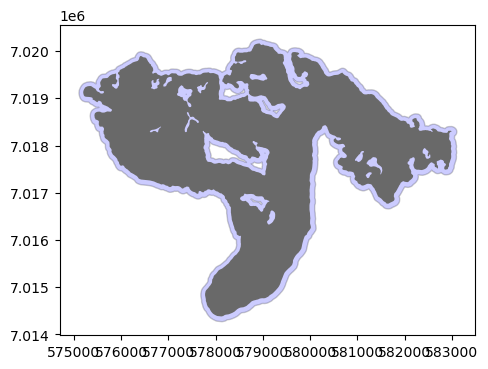

In [5]:
fig, ax = plt.subplots(figsize=(5,5))

glacier_utm_df.plot(ax=ax, color='dimgrey', zorder=2) # plot this one on top 'zorder'
glacier_utm_buff_df.plot(ax=ax, color='b', edgecolor='k', linewidth=1, linestyle='-', alpha=0.2, zorder=1)
ax2.set_xlabel('UTM Easting (m)')
ax2.set_ylabel('UTM Northing (m)')

fig.tight_layout()
plt.show()
# see the original shape (grey) and the buffered shape (light blue)


### Working with raster data

For example, geotiff

In [6]:
# locate data
hug_dhdt_fp = '/Users/albwel/data/hugonnet_dhdt/01_02_rgi60_2000-01-01_2020-01-01/dhdt/N63W146_2000-01-01_2020-01-01_dhdt.tif'

# open data -- can also use xarray like in the other notebook. the gist is the same
hug_dhdt_ras = rasterio.open(hug_dhdt_fp)

# assess crs, resolution, extent
print(hug_dhdt_ras.crs, hug_dhdt_ras.res, hug_dhdt_ras.bounds)
# UTM coordinates, 100 m resolution


EPSG:32606 (100.0, 100.0) BoundingBox(left=548650.0, bottom=6992150.0, right=601550.0, top=7063850.0)


In [7]:
# the easiest way to work with raster (tif) data in python is by loading them as an array (basically a matrix)
hug_dhdt_arr = hug_dhdt_ras.read(1)
print(hug_dhdt_arr) # now we have a matrix of values


[[-9.9990000e+03 -9.9990000e+03 -9.9990000e+03 ... -9.9990000e+03
  -9.9990000e+03 -9.9990000e+03]
 [-9.9990000e+03 -9.9990000e+03 -9.9990000e+03 ... -9.9990000e+03
  -9.9990000e+03 -9.9990000e+03]
 [-9.9990000e+03 -9.9990000e+03 -9.9990000e+03 ... -9.9990000e+03
  -9.9990000e+03 -9.9990000e+03]
 ...
 [-9.9990000e+03 -9.9990000e+03 -9.9990000e+03 ... -1.4166871e-01
  -6.4837649e-02 -9.9990000e+03]
 [-9.9990000e+03 -9.9990000e+03 -9.9990000e+03 ... -9.9990000e+03
  -1.4727783e-01 -9.9990000e+03]
 [-9.9990000e+03 -9.9990000e+03 -9.9990000e+03 ... -9.9990000e+03
  -9.9990000e+03 -9.9990000e+03]]


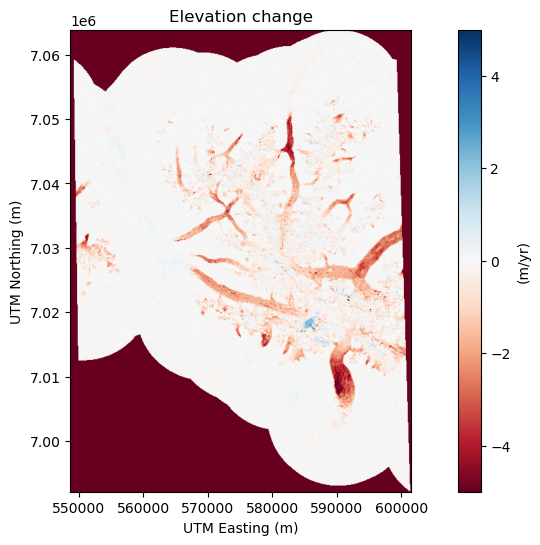

In [9]:
bounds = hug_dhdt_ras.bounds  # BoundingBox(left, bottom, right, top)
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

# plot data
fig, ax = plt.subplots(figsize=(12,6))

divnorm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
c = ax.imshow(hug_dhdt_arr, cmap='RdBu', extent=extent, norm=divnorm)
ax.set_xlabel('UTM Easting (m)')
ax.set_ylabel('UTM Northing (m)')
ax.set_title('Elevation change')
fig.colorbar(c, label='(m/yr)')
plt.show()
# clearly there's some 'NaN' data around the edges (would be in the file metadata) and this is a large region
# let's zoom to our glacier, using our glacier outline


Crop

In [10]:
# crop raster using shapefile (note: we want to use the shapefile reprojected to the same coordinate system)
out_fp = '/Users/albwel/Desktop/raster_crop.tif' # output filepath to save the result

# convert shapefile geometries to geojson-like mapping
shapes = [feature['geometry'] for feature in glacier_utm_df.__geo_interface__['features']]

# crop the raster
out_image, out_transform = mask(hug_dhdt_ras, shapes, crop=True)

# copy the metadata and update for the new raster
out_meta = hug_dhdt_ras.meta.copy()
out_meta.update({
    'height': out_image.shape[1],
    'width': out_image.shape[2],
    'transform': out_transform
})

# save the cropped raster
with rasterio.open(out_fp, 'w', **out_meta) as dest:
    dest.write(out_image)
    

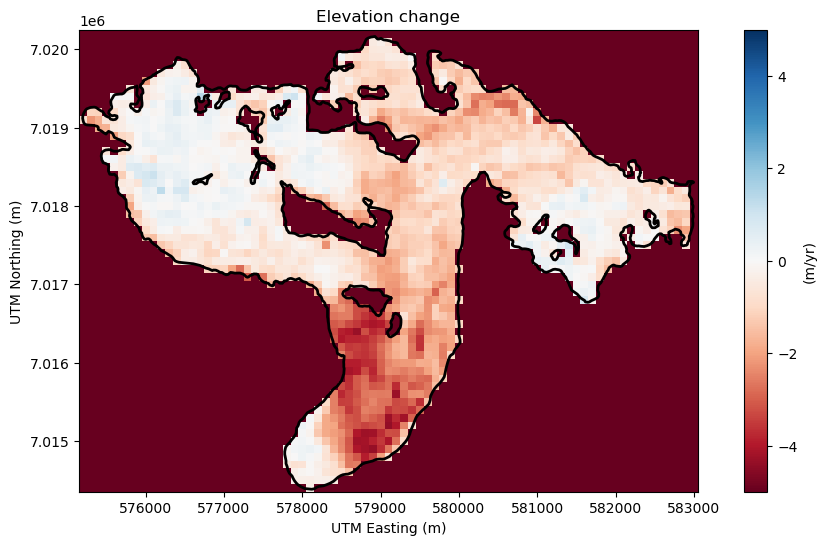

In [11]:
# open new file
crop_ras = rasterio.open(out_fp)
bounds = crop_ras.bounds  # BoundingBox(left, bottom, right, top)
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

# plot data
fig, ax = plt.subplots(figsize=(12,6))

divnorm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
c = ax.imshow(crop_ras.read(1), cmap='RdBu', extent=extent, norm=divnorm)
ax.set_xlabel('UTM Easting (m)')
ax.set_ylabel('UTM Northing (m)')
ax.set_title('Elevation change')
fig.colorbar(c, label='(m/yr)')

# add shapefile
glacier_utm_df.plot(ax=ax, color='none', edgecolor='k', linewidth=2)

plt.show()
# we've cropped the raster to the shapefile!


In [12]:
crop_arr = crop_ras.read(1)
crop_arr_nan = crop_arr.copy()
crop_arr_nan[crop_arr_nan == -9999] = np.nan # filter out nan values, which are -9999
dV_ann = np.nansum(crop_arr_nan)*crop_ras.res[0]*crop_ras.res[1] # annual estimate ice volume loss (multiply by grid size) (cubic m / yr)
dM_ann = dV_ann * 850 # annual estimate ice mass loss (density assumption: 850 kg/m3) (kg / yr)
dSMB_ann = dM_ann / glacier_utm_df.geometry.area.values[0] # annual estimate mass balance (kg / m2 yr) or (mm w.e.a. "meter water equivalent annual")
dSMB_ann_m = dSMB_ann / 1000 # convert units from mm w.e.a to m w.e.a

print(f'Mean annual glacier mass loss 2000-2020: {dV_ann:.0f} (m^3/yr)') 
print(f'Mean annual glacier mass balance 2000-2020: {dSMB_ann_m:.2f} (m w.e.a.)') # the :.2f just rounds the printed value to 2 decimals


Mean annual glacier mass loss 2000-2020: -16783676 (m^3/yr)
Mean annual glacier mass balance 2000-2020: -0.81 (m w.e.a.)


Reproject -- this is also how you can clip the extent and change the resolution

In [13]:
# let's reproject the out_fp

# some options:
crs_out = 'EPSG:3338' # target coordinate system -- let's do Alaska Albers for this example in Alaska
res_out = 10 # output resolution -- let's make it much smaller than the 100 m. This isn't a good idea to upscale, but you can see what it looks like
nodata_val = np.nan # value to fill if reprojected extent is larger than current extent
extent_file = None # option to enter a filepath (e.g. 'thickness.tif') to match the extent of the reprojected file
reproj_fp = '/Users/albwel/Desktop/raster_reproj.tif' # output filename

with rasterio.open(out_fp) as src:
    # Determine target transform, width, height
    if extent_file is None:
        transform, width, height = calculate_default_transform(src.crs, crs_out, src.width, src.height, *src.bounds, resolution=res_out)
    else:
        with rasterio.open(extent_file) as dst:
            transform, width, height = calculate_default_transform(src.crs, crs_out, dst.width, dst.height, *dst.bounds, resolution=res_out)

    # update metadata
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': crs_out,
        'transform': transform,
        'width': width,
        'height': height,
        'nodata': nodata_val
    })

    # reproject
    with rasterio.open(reproj_fp, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs_out,
            dst_nodata=nodata_val,
            resampling=Resampling.cubic_spline # resampling interpolation scheme
        )
        

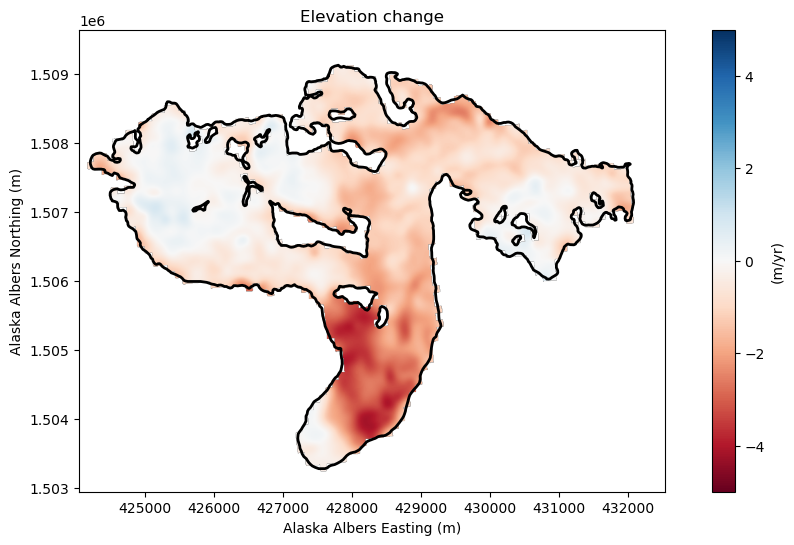

In [14]:
# # plot result
reproj_ras = rasterio.open(reproj_fp)
bounds = reproj_ras.bounds  # BoundingBox(left, bottom, right, top)
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

fig, ax = plt.subplots(figsize=(12,6))
divnorm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
c = ax.imshow(reproj_ras.read(1), cmap='RdBu', extent=extent, norm=divnorm)
ax.set_xlabel('Alaska Albers Easting (m)')
ax.set_ylabel('Alaska Albers Northing (m)')
ax.set_title('Elevation change')
fig.colorbar(c, label='(m/yr)')

# add shapefile -- we need to reproject this in order to show it on the same plot!!
glacier_ak_df = glacier_df.to_crs('EPSG:3338')
glacier_ak_df.plot(ax=ax, color='none', edgecolor='k', linewidth=2)

plt.show()
# we've cropped the raster to the shapefile! notice how we filled the area with np.nan directly during reprojection


In [15]:
# let's see: our calculations should be basically the same
reproj_arr = reproj_ras.read(1)
reproj_arr_nan = reproj_arr.copy()
# reproj_arr_nan[reproj_arr_nan == -9999] = np.nan # skip this step since the values are already NaN
dV_ann = np.nansum(reproj_arr_nan)*reproj_ras.res[0]*reproj_ras.res[1] # annual estimate ice volume loss (multiply by grid size) (cubic m / yr)
dM_ann = dV_ann * 850 # annual estimate ice mass loss (density assumption: 850 kg/m3) (kg / yr)
dSMB_ann = dM_ann / glacier_utm_df.geometry.area.values[0] # annual estimate mass balance (kg / m2 yr) or (mm w.e.a. "meter water equivalent annual")
dSMB_ann_m = dSMB_ann / 1000 # convert units from mm w.e.a to m w.e.a

print(f'Mean annual glacier mass loss 2000-2020: {dV_ann:.0f} (m^3/yr)') 
print(f'Mean annual glacier mass balance 2000-2020: {dSMB_ann_m:.2f} (m w.e.a.)') # the :.2f just rounds the printed value to 2 decimals
# basically the same! slightly different due to the interpolation during reprojection


Mean annual glacier mass loss 2000-2020: -16788518 (m^3/yr)
Mean annual glacier mass balance 2000-2020: -0.81 (m w.e.a.)


In [16]:
# if you have multiple rasters with the same coordinate system, extent, and resolution
    # you can use numpy to perform calculations with the 2D arrays
